# 02 - Build train / val / test splits

Constructs reproducible link-prediction splits on the PlantMetWiki heterogeneous graph and saves them to `data/processed/splits.pt`.

## Overview

### Goal
Construct **reproducible, biologically meaningful train / val / test splits** for link prediction on the PlantMetWiki heterogeneous graph, and characterise each split with statistics and visualisations.

---

### Prediction target
**`(Protein, catalyzes, Interaction)`** — a directly persisted edge on `heterodata.pt` since the
v3 graph redesign (`01_explore_graph.ipynb` Section 9 / `scripts/redesign_graph_v3.py`), which
collapsed the reified `Catalysis` node into this edge and removed it from the graph. Its
destination nodes are always `Conversion`-subtype `Interaction` nodes, i.e. reactions. See
`01_explore_graph.ipynb` Sections 6-9 for the full subtype analysis and the redesign that produced
this edge.

Its inverse `(Interaction, catalyzed_by, Protein)` is masked jointly in every split to
prevent the model from trivially inferring target edges from their reverse.

---

### Splitting strategies

| # | Strategy | Description | When to use |
|---|----------|-------------|-------------|
| 1 | **Random (80/10/10)** | Edges shuffled and split uniformly at random. Negative samples drawn at 1:1 ratio. | Baseline; fastest to run; assumes i.i.d. edges. |
| 2 | **Taxa (organism-stratified)** | Entire organisms held out for val/test. Edges shared across train and val/test organisms stay in train (leakage-free). Greedy filling keeps ~80/10/10 edge balance. Built in `notebooks/03_embeddings_fulldata.ipynb` §7.7/§7.8 (needs embedding coverage to pick held-out organisms correctly — see Section 5 below). | Tests generalisation across species — the realistic deployment scenario for a plant metabolomics tool. |
| 3 | **Reaction-type (EC class)** | *(planned)* Held-out EC classes or sub-classes. | Tests generalisation to unseen reaction chemistry. |
| 4 | **Pathway-balanced** | *(planned)* Whole pathways removed for val/test, sampled proportionally to pathway size. | Tests generalisation to unseen biological contexts. |

---

### Steps in this notebook

1. **Setup** — load `heterodata.pt`, set random seed.
2. **Inspect edge types** — confirm target and reverse edge counts.
3. **Random split** — apply `RandomLinkSplit` (PyG); inspect message-passing vs. label edges.
4. **Save random splits** → `data/processed/splits.pt`
5. **Taxa split** — moved to `notebooks/03_embeddings_fulldata.ipynb` §7.7/§7.8: building it
   here would run before any embedding exists, and the organism selection needs embedding
   coverage to avoid landing val/test in the near-zero-coverage tail (see that section's
   diagnosis). Still saves to `data/processed/splits_taxa.pt`.
6. **Pathway-balanced split** — built here (Section 6 below), independent of embeddings.

---

### Metrics and diagnostics

| Metric | What it measures |
|--------|-----------------|
| **Edge counts per split** | Whether the 80/10/10 target is achieved in practice. |
| **Organism / pathway counts per split** | Coverage of biological entities across splits. |
| **Tanimoto similarity (organism pairs)** | Biochemical overlap between organisms; guides which ones to hold out. |
| **Cross-split Tanimoto (protein sets)** | Key diagnostic: low Train∩Val / Train∩Test (< 0.4) means the split is genuinely out-of-distribution. |
| **Excluded edges** | Target edges whose protein is multi-label or has only the "unknown organism" fallback taxon — always placed in train. |

## Splitting strategy

**Target edge type:** `(Protein, catalyzes, Interaction)` — derived by restricting
`(Protein, is_part_of, Interaction)` to its `Catalysis` subtype (~12.4 k of ~20.6 k edges; see
`01_explore_graph.ipynb` Sections 6-8). This is the "enzyme catalyses reaction" relationship,
the primary missing-link prediction target.

**Protocol (first pass — random split):**
- 80 / 10 / 10 train / val / test on edges of the target type
- `(Interaction, catalyzed_by, Protein)` (the derived semantic inverse) is masked jointly to prevent leakage
- Negative samples drawn uniformly at random at ratio 1:1
- Species-held-out split comes later once the pipeline is validated

**Output:** `data/processed/splits.pt` — a dict with keys `train`, `val`, `test` (each a `HeteroData`) plus metadata.

In [1]:
from pathlib import Path
import torch
import pandas as pd
from torch_geometric.transforms import RandomLinkSplit

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"

HETERO_PATH = DATA_DIR / "heterodata.pt"
SPLITS_PATH = DATA_DIR / "splits.pt"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

print(f"Torch {torch.__version__}")
print(f"heterodata.pt: {'OK' if HETERO_PATH.exists() else 'MISSING – run scripts/build_pyg.py'}")

/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch 2.4.1+cu121
heterodata.pt: OK


In [2]:
data = torch.load(HETERO_PATH, weights_only=False)
print(data)
print()

# Summarise all edge types with counts to inform target selection
for et in data.edge_types:
    n = data[et].edge_index.shape[1]
    print(f"  {et[0]} -[{et[1]}]-> {et[2]} : {n:,}")

HeteroData(
  GeneProduct={ num_nodes=6480 },
  Interaction={ num_nodes=84470 },
  Metabolite={ num_nodes=17476 },
  Organism={ num_nodes=424 },
  Pathway={ num_nodes=2478 },
  Protein={ num_nodes=13682 },
  (GeneProduct, encodes, Protein)={ edge_index=[2, 2762] },
  (GeneProduct, is_about, GeneProduct)={ edge_index=[2, 4580] },
  (GeneProduct, is_part_of, Pathway)={ edge_index=[2, 8215] },
  (GeneProduct, organism, Organism)={ edge_index=[2, 6504] },
  (Interaction, catalyzed_by, Protein)={ edge_index=[2, 11980] },
  (Interaction, is_about, Interaction)={ edge_index=[2, 29740] },
  (Interaction, is_part_of, Interaction)={ edge_index=[2, 9813] },
  (Interaction, is_part_of, Pathway)={ edge_index=[2, 29740] },
  (Interaction, participants, Interaction)={ edge_index=[2, 9813] },
  (Interaction, participants, Metabolite)={ edge_index=[2, 34793] },
  (Interaction, source, Metabolite)={ edge_index=[2, 7554] },
  (Interaction, target, Interaction)={ edge_index=[2, 17] },
  (Interaction, targ

## 1. Choose prediction target

`(Protein, catalyzes, Interaction)` is now a **directly persisted edge** on `heterodata.pt`
(`Catalysis`-subtype reified nodes no longer exist at all -- collapsed and removed by
`scripts/redesign_graph_v3.py`, see `01_explore_graph.ipynb` Section 9, which built on the
cardinality check in Section 8.1: every `Catalysis` node had exactly one `Protein` and one
`Conversion` neighbour). Its destination nodes are always `Conversion`-subtype `Interaction`
nodes -- "this protein catalyses this reaction".

Its inverse `(Interaction, catalyzed_by, Protein)` is also a persisted edge, masked jointly in
every split so the model cannot trivially infer target edges from their reverse.

In [3]:
# -- (Protein, catalyzes, Interaction) is now a real persisted edge --
# scripts/redesign_graph_v3.py (see 01_explore_graph.ipynb Section 9) collapsed
# Protein -> Catalysis -> Conversion into this direct edge (+ its reverse,
# catalyzed_by) at graph-build time, and removed the Catalysis/
# TranscriptionTranslation reified nodes entirely. No runtime chaining is
# needed any more -- this cell just reads it straight off heterodata.pt.
nodes = pd.read_csv(DATA_DIR / "nodes.tsv", sep="\t")

TARGET_EDGE = ("Protein", "catalyzes", "Interaction")
REV_EDGE    = ("Interaction", "catalyzed_by", "Protein")

n_target = data[TARGET_EDGE].edge_index.shape[1]
n_rev    = data[REV_EDGE].edge_index.shape[1]

print(f"Target  {TARGET_EDGE} (dst is always Conversion-subtype): {n_target:,} edges")
print(f"Inverse {REV_EDGE}: {n_rev:,} edges")
print()
print(f"Expected val  edges (positive): ~{int(n_target * 0.1):,}")
print(f"Expected test edges (positive): ~{int(n_target * 0.1):,}")

Target  ('Protein', 'catalyzes', 'Interaction') (dst is always Conversion-subtype): 11,980 edges
Inverse ('Interaction', 'catalyzed_by', 'Protein'): 11,980 edges

Expected val  edges (positive): ~1,198
Expected test edges (positive): ~1,198


## 2. Apply RandomLinkSplit (80 / 10 / 10)

In [4]:
transform = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=[TARGET_EDGE],
    rev_edge_types=[REV_EDGE],
)

train_data, val_data, test_data = transform(data)
print("Split complete.")

Split complete.


## 3. Inspect split statistics

In [5]:
def split_summary(name, split):
    ei = split[TARGET_EDGE].edge_label_index
    el = split[TARGET_EDGE].edge_label
    mp = split[TARGET_EDGE].edge_index        # edges kept for message passing
    n_pos = int((el == 1).sum())
    n_neg = int((el == 0).sum())
    print(f"{name:6s}  MP edges: {mp.shape[1]:6,}  |  labels: {n_pos:5,} pos  {n_neg:5,} neg")

split_summary("Train", train_data)
split_summary("Val  ", val_data)
split_summary("Test ", test_data)

total_target = data[TARGET_EDGE].edge_index.shape[1]
train_pos = int((train_data[TARGET_EDGE].edge_label == 1).sum())
val_pos   = int((val_data[TARGET_EDGE].edge_label   == 1).sum())
test_pos  = int((test_data[TARGET_EDGE].edge_label  == 1).sum())
print()
print(f"Positive edges: train {train_pos/total_target:.0%} | val {val_pos/total_target:.0%} | test {test_pos/total_target:.0%}")

Train   MP edges:  9,584  |  labels: 9,584 pos  9,584 neg
Val     MP edges:  9,584  |  labels: 1,198 pos  1,198 neg
Test    MP edges: 10,782  |  labels: 1,198 pos  1,198 neg

Positive edges: train 80% | val 10% | test 10%


## 4. Save splits

In [6]:
torch.save(
    {
        "train": train_data,
        "val":   val_data,
        "test":  test_data,
        "target_edge": TARGET_EDGE,
        "rev_edge":    REV_EDGE,
        "split_params": {
            "num_val": 0.1,
            "num_test": 0.1,
            "neg_sampling_ratio": 1.0,
            "random_seed": RANDOM_SEED,
        },
    },
    SPLITS_PATH,
)
print(f"Saved -> {SPLITS_PATH}")

Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/splits.pt


## 5. Organism-stratified (taxa) split — moved to `notebooks/03_embeddings_fulldata.ipynb` §7.7/§7.8

This used to build `data/processed/splits_taxa.pt` here, by mapping each target edge through
`Protein → organism → Organism` and greedily holding out organisms by target-edge count. That
selection turned out to be **blind to embedding coverage** — it ran before any embedding existed,
so it could (and did) land its held-out organisms in the near-zero embedding-coverage tail (train
organisms averaged ~64% Protein embedding coverage, the old held-out val organisms averaged ~9%).
See `03_embeddings_fulldata.ipynb` §7.7 for the diagnosis and §7.8 for the embedding-coverage-aware
rebuild — same greedy algorithm, plus a minimum per-organism coverage gate before an organism is
eligible for val/test. That section is the canonical place `splits_taxa.pt` is now built; re-run it
(not this notebook) to regenerate that file.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR   = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Target edges & their pathway membership -- both reused by the pathway-
# balanced split in Section 6 (the only consumer left in this notebook; the
# taxa split that used to also build on these moved to
# notebooks/03_embeddings_fulldata.ipynb §7.7/§7.8, see Section 5 above).
prot_int = pd.DataFrame({
    "protein_idx":     data[TARGET_EDGE].edge_index[0].numpy(),
    "interaction_idx": data[TARGET_EDGE].edge_index[1].numpy(),
})
int_path = pd.DataFrame({
    "interaction_idx": data[("Interaction", "is_part_of", "Pathway")].edge_index[0].numpy(),
    "pathway_idx":     data[("Interaction", "is_part_of", "Pathway")].edge_index[1].numpy(),
})
n_total = len(prot_int)
print(f"Target edges available for splitting: {n_total:,}")

def set_tanimoto(a, b):
    i = len(a & b); u = len(a | b)
    return i / u if u else 0.0

def tanimoto_flag(t, lo=0.4, hi=0.6):
    if t < lo:  return "✓ low — good out-of-distribution signal"
    if t < hi:  return "⚠ moderate — acceptable but check organism choice"
    return            "✗ high — consider more taxonomically distant organisms"

Target edges available for splitting: 11,980


## 6. Pathway-balanced split

Maps target edges to the pathways they belong to via  
`Protein → is_part_of → Interaction → is_part_of → Pathway`  
then holds out entire pathways for val/test.

**Scientific question this split answers:**  
*"Can the model predict missing enzyme–reaction links for pathway contexts it has never seen during training?"*  
This is complementary to the taxa split: instead of generalising across species, the model must generalise across biological processes (e.g., trained on glycolysis, evaluated on a novel secondary metabolism pathway).

In [8]:
PATHWAY_SPLITS_PATH = DATA_DIR / "splits_pathway.pt"

# ── Pathway labels from nodes.tsv ──────────────────────────────────────────────
pathway_nodes = (
    nodes[nodes["node_type"] == "Pathway"]
    .reset_index(drop=True)
    .rename_axis("pathway_idx")
    .reset_index()
)
pathway_nodes["pathway_name"] = pathway_nodes["node_id"].str.rsplit("/", n=1).str[-1]

# ── Pathway → target-edge mapping ─────────────────────────────────────────────
path_to_targets = (
    prot_int
    .merge(int_path, on="interaction_idx")
    .drop_duplicates(["protein_idx", "interaction_idx", "pathway_idx"])
)

# Pathway size as number of distinct target (protein, interaction) pairs
pw_target_sizes = (
    path_to_targets.groupby("pathway_idx")
    .size().reset_index(name="n_target_edges")
)

# Pathway "steps" = distinct Interaction nodes (biochemical reactions)
pw_steps = (
    int_path.groupby("pathway_idx")["interaction_idx"]
    .nunique().reset_index(name="n_steps")
)

pathway_stats = (
    pw_target_sizes
    .merge(pw_steps, on="pathway_idx", how="outer")
    .merge(pathway_nodes[["pathway_idx", "pathway_name"]], on="pathway_idx", how="left")
)
pathway_stats["n_target_edges"] = pathway_stats["n_target_edges"].fillna(0).astype(int)
pathway_stats["n_steps"]        = pathway_stats["n_steps"].fillna(0).astype(int)
pathway_stats = pathway_stats.sort_values("n_target_edges", ascending=False).reset_index(drop=True)

# Target edges covered by at least one pathway
n_covered = path_to_targets[["protein_idx","interaction_idx"]].drop_duplicates().shape[0]
n_pw_with_targets = (pathway_stats["n_target_edges"] > 0).sum()

print(f"Total pathways                  : {len(pathway_stats):,}")
print(f"Pathways with ≥1 target edge    : {n_pw_with_targets:,}")
print(f"Target edges covered by pathways: {n_covered:,} / {n_total:,} ({100*n_covered/n_total:.1f}%)")
print()
print("Pathway size stats (target edges per pathway):")
sizes = pathway_stats[pathway_stats["n_target_edges"] > 0]["n_target_edges"]
print(f"  mean={sizes.mean():.1f}  median={sizes.median():.0f}  "
      f"max={sizes.max():,}  min={sizes.min()}")
print()
print("Top 15 pathways by target edge count:")
print(pathway_stats.head(15)[["pathway_name","n_target_edges","n_steps"]].to_string(index=False))

Total pathways                  : 2,476
Pathways with ≥1 target edge    : 1,608
Target edges covered by pathways: 11,980 / 11,980 (100.0%)

Pathway size stats (target edges per pathway):
  mean=7.5  median=3  max=193  min=1

Top 15 pathways by target edge count:
                  pathway_name  n_target_edges  n_steps
  PC50_r17.0.0_20260605-171052             193      181
 PC332_r17.0.0_20260605-171052             142       80
 PC356_r17.0.0_20260605-171052             140       24
 PC857_r17.0.0_20260605-171052             126      156
 PC675_r17.0.0_20260605-171052             125       42
 PC870_r17.0.0_20260605-171052             122       12
 PC504_r17.0.0_20260605-171052              99       70
 PC861_r17.0.0_20260605-171052              99       16
PC1113_r17.0.0_20260605-171052              86       28
 PC360_r17.0.0_20260605-171052              73       77
 PC812_r17.0.0_20260605-171052              70       21
 PC420_r17.0.0_20260605-171052              67       26
 PC152_r1

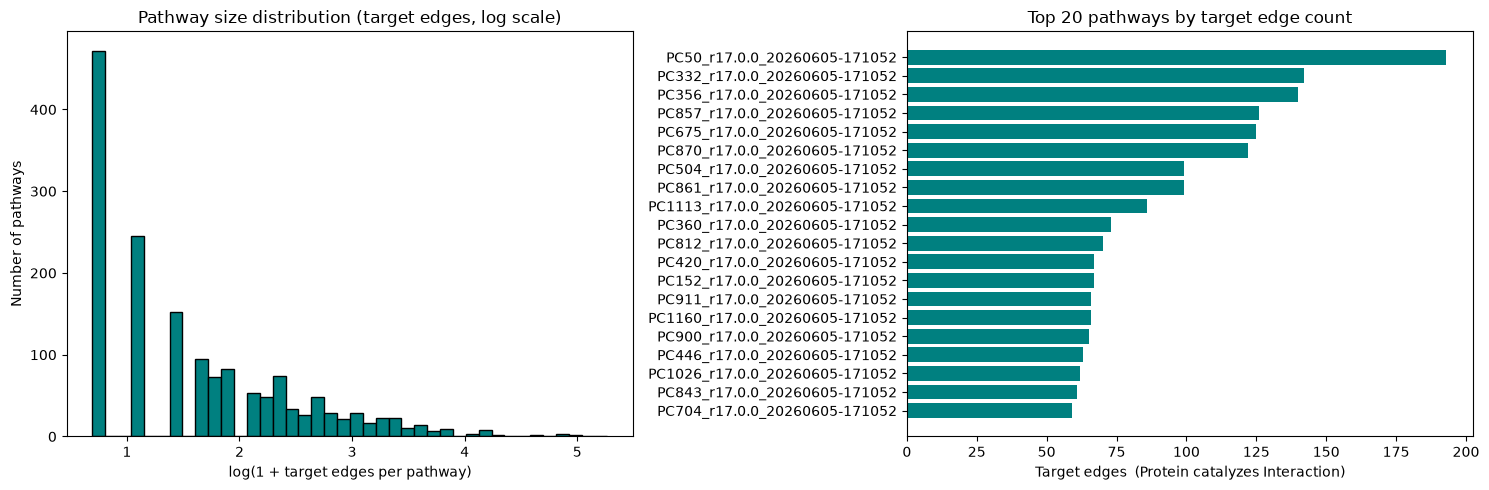

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pw_pos = pathway_stats[pathway_stats["n_target_edges"] > 0]

# Left: size distribution
axes[0].hist(np.log1p(pw_pos["n_target_edges"]), bins=40, edgecolor="black", color="teal")
axes[0].set_xlabel("log(1 + target edges per pathway)")
axes[0].set_ylabel("Number of pathways")
axes[0].set_title("Pathway size distribution (target edges, log scale)")

# Right: top 20 pathways
top20 = pw_pos.head(20)
axes[1].barh(top20["pathway_name"][::-1], top20["n_target_edges"][::-1], color="teal")
axes[1].set_xlabel("Target edges  (Protein catalyzes Interaction)")
axes[1].set_title("Top 20 pathways by target edge count")

plt.tight_layout()
fig.savefig(FIG_DIR / "pathway_size_distribution.png")
plt.show()

pathway_stats.to_csv(TABLE_DIR / "pathway_sizes.tsv", sep="\t", index=False)

### 6.1 Sampling strategy — size-proportional random selection

#### Why not just pick the largest pathways?
Selecting only large pathways for val/test would bias evaluation towards well-annotated hub pathways (e.g., central carbon metabolism) and leave small, specialised pathways always in train. A model could score well by memorising large-pathway chemistry without learning anything about rare biosynthetic routes.

#### Size-proportional weighted shuffle
Pathways are assigned to a random permutation where each pathway's probability of appearing early is **proportional to its number of target edges**. We then greedily fill val until ≥ 10 % of total target edges are reached, then test for another ≥ 10 %. This guarantees:
- Larger pathways are more likely to be selected (so we reach the 10 % threshold without needing thousands of tiny pathways)
- The selection is still random — not deterministic top-N — so the split is representative of the full size distribution
- The random seed makes the split fully reproducible

#### Leakage handling — strict rule
An edge is assigned to val (or test) only if **none** of its pathways is a training pathway.

*Why strict here (unlike taxa)?*  
For the pathway split the scientific question is pathway-context generalisation. If a reaction appears in both glycolysis (train) and gluconeogenesis (val), the model was trained on that exact (Protein, Interaction) pair from the glycolysis pathway. Predicting it in gluconeogenesis is not a test of generalisation — it is recall. The strict rule ensures val/test edges are genuinely novel pathway contexts.

*Trade-off:* Interactions shared across many pathways will tend to stay in train, making val/test consist of pathway-exclusive reactions — which is precisely the biologically interesting held-out set. If the strict rule gives too few edges, the pathway size distribution (above) can guide a decision to relax it.

In [10]:
# ── Size-proportional weighted shuffle ────────────────────────────────────────
pw_pos = pathway_stats[pathway_stats["n_target_edges"] > 0].copy()
n_pw   = len(pw_pos)

rng   = np.random.default_rng(RANDOM_SEED)
probs = pw_pos["n_target_edges"].values.astype(float)
probs /= probs.sum()

order      = rng.choice(n_pw, size=n_pw, replace=False, p=probs)
shuffled_pw = pw_pos.iloc[order].reset_index(drop=True)
cumsum      = shuffled_pw["n_target_edges"].cumsum()

val_cut  = int((cumsum <  0.10 * n_total).sum())
test_cut = int((cumsum <  0.20 * n_total).sum())

val_pathways   = set(shuffled_pw.iloc[:val_cut]["pathway_idx"])
test_pathways  = set(shuffled_pw.iloc[val_cut:test_cut]["pathway_idx"])
train_pathways = set(pw_pos["pathway_idx"]) - val_pathways - test_pathways

print(f"Train pathways : {len(train_pathways):4d}")
print(f"Val   pathways : {len(val_pathways):4d}")
print(f"Test  pathways : {len(test_pathways):4d}")
print()

# ── Strict edge assignment ─────────────────────────────────────────────────────
# Edge → val/test only if NONE of its pathways is a training pathway
edge_pw_map = (
    path_to_targets
    .groupby(["protein_idx", "interaction_idx"])["pathway_idx"]
    .apply(frozenset).reset_index(name="pathways")
)

def assign_split_pw(pathways):
    has_train = bool(pathways & train_pathways)
    has_val   = bool(pathways & val_pathways)
    has_test  = bool(pathways & test_pathways)
    if   has_val  and not has_train: return "val"
    elif has_test and not has_train: return "test"
    else:                            return "train"

edge_pw_map["split"] = edge_pw_map["pathways"].apply(assign_split_pw)

# Edges in no pathway → train
no_pw_mask = ~prot_int.set_index(["protein_idx","interaction_idx"]).index.isin(
    edge_pw_map.set_index(["protein_idx","interaction_idx"]).index
)
no_pw_df          = prot_int[no_pw_mask].copy()
no_pw_df["pathways"] = [frozenset()] * len(no_pw_df)
no_pw_df["split"]    = "train"

all_edges_pw = pd.concat([edge_pw_map, no_pw_df], ignore_index=True)

sc_pw = all_edges_pw["split"].value_counts()
print("Edge assignment:")
for s in ["train", "val", "test"]:
    print(f"  {s:5s}: {sc_pw.get(s,0):6,}  ({100*sc_pw.get(s,0)/n_total:.1f}%)")

Train pathways : 1527
Val   pathways :   47
Test  pathways :   34



Edge assignment:
  train:  9,612  (80.2%)
  val  :  1,191  (9.9%)
  test :  1,177  (9.8%)


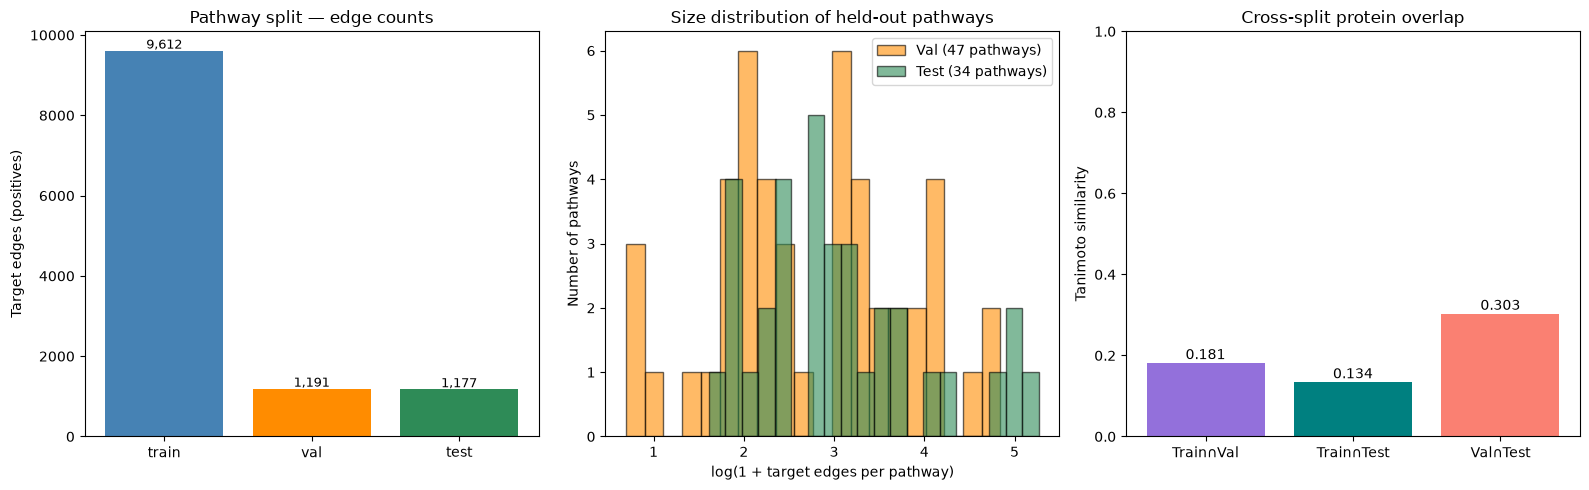

Cross-split Tanimoto — protein sets:
  Train vs Val : 0.1810
  Train vs Test: 0.1338
  Val vs Test  : 0.3027

Cross-split Tanimoto — interaction sets:
  Train vs Val : 0.0000
  Train vs Test: 0.0000
  Val vs Test  : 0.0000


In [11]:
# ── Cross-split metrics ────────────────────────────────────────────────────────
def split_pw_protein_set(split_name):
    return set(all_edges_pw[all_edges_pw["split"] == split_name]["protein_idx"].values)

def split_pw_interaction_set(split_name):
    return set(all_edges_pw[all_edges_pw["split"] == split_name]["interaction_idx"].values)

train_pw_prots = split_pw_protein_set("train")
val_pw_prots   = split_pw_protein_set("val")
test_pw_prots  = split_pw_protein_set("test")

tan_pw_tv = set_tanimoto(train_pw_prots, val_pw_prots)
tan_pw_tt = set_tanimoto(train_pw_prots, test_pw_prots)
tan_pw_vt = set_tanimoto(val_pw_prots,   test_pw_prots)

train_pw_ints = split_pw_interaction_set("train")
val_pw_ints   = split_pw_interaction_set("val")
test_pw_ints  = split_pw_interaction_set("test")

tan_int_tv = set_tanimoto(train_pw_ints, val_pw_ints)
tan_int_tt = set_tanimoto(train_pw_ints, test_pw_ints)
tan_int_vt = set_tanimoto(val_pw_ints,   test_pw_ints)

# ── Size distribution of val/test pathways ─────────────────────────────────────
val_pw_stats  = pathway_stats[pathway_stats["pathway_idx"].isin(val_pathways)]
test_pw_stats = pathway_stats[pathway_stats["pathway_idx"].isin(test_pathways)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Edge counts
splits_pw = ["train", "val", "test"]
colors_pw = ["steelblue", "darkorange", "seagreen"]
axes[0].bar(splits_pw, [sc_pw.get(s, 0) for s in splits_pw], color=colors_pw)
for i, s in enumerate(splits_pw):
    axes[0].text(i, sc_pw.get(s, 0) + 50, f"{sc_pw.get(s,0):,}", ha="center", fontsize=9)
axes[0].set_ylabel("Target edges (positives)")
axes[0].set_title("Pathway split — edge counts")

# 2. Pathway size distributions (val vs test)
axes[1].hist(np.log1p(val_pw_stats["n_target_edges"]),  bins=20, alpha=0.6,
             label=f"Val ({len(val_pathways)} pathways)",  color="darkorange", edgecolor="black")
axes[1].hist(np.log1p(test_pw_stats["n_target_edges"]), bins=20, alpha=0.6,
             label=f"Test ({len(test_pathways)} pathways)", color="seagreen",    edgecolor="black")
axes[1].set_xlabel("log(1 + target edges per pathway)")
axes[1].set_ylabel("Number of pathways")
axes[1].set_title("Size distribution of held-out pathways")
axes[1].legend()

# 3. Cross-split Tanimoto (protein sets)
tan_labels = ["Train∩Val", "Train∩Test", "Val∩Test"]
tan_vals   = [tan_pw_tv, tan_pw_tt, tan_pw_vt]
axes[2].bar(tan_labels, tan_vals, color=["mediumpurple", "teal", "salmon"])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Tanimoto similarity")
axes[2].set_title("Cross-split protein overlap")
for i, v in enumerate(tan_vals):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(FIG_DIR / "pathway_split_stats.png")
plt.show()

print("Cross-split Tanimoto — protein sets:")
print(f"  Train vs Val : {tan_pw_tv:.4f}")
print(f"  Train vs Test: {tan_pw_tt:.4f}")
print(f"  Val vs Test  : {tan_pw_vt:.4f}")
print()
print("Cross-split Tanimoto — interaction sets:")
print(f"  Train vs Val : {tan_int_tv:.4f}")
print(f"  Train vs Test: {tan_int_tt:.4f}")
print(f"  Val vs Test  : {tan_int_vt:.4f}")

In [12]:
from IPython.display import Markdown

# ── Save ───────────────────────────────────────────────────────────────────────
def make_pw_edge_index(split_name):
    sub = all_edges_pw[all_edges_pw["split"] == split_name]
    return torch.stack([
        torch.tensor(sub["protein_idx"].values,     dtype=torch.long),
        torch.tensor(sub["interaction_idx"].values, dtype=torch.long),
    ], dim=0)

train_pw_ei = make_pw_edge_index("train")
val_pw_ei   = make_pw_edge_index("val")
test_pw_ei  = make_pw_edge_index("test")

torch.save(
    {
        "train_edge_index": train_pw_ei,
        "val_edge_index":   val_pw_ei,
        "test_edge_index":  test_pw_ei,
        "target_edge":      TARGET_EDGE,
        "train_pathways":   sorted(train_pathways),
        "val_pathways":     sorted(val_pathways),
        "test_pathways":    sorted(test_pathways),
        "split_params": {
            "strategy":          "pathway_size_proportional",
            "leakage_rule":      "strict",
            "val_target_frac":   0.10,
            "test_target_frac":  0.10,
            "random_seed":       RANDOM_SEED,
        },
        "tanimoto": {
            "proteins": {"train_val": float(tan_pw_tv), "train_test": float(tan_pw_tt), "val_test": float(tan_pw_vt)},
            "interactions": {"train_val": float(tan_int_tv), "train_test": float(tan_int_tt), "val_test": float(tan_int_vt)},
        },
    },
    PATHWAY_SPLITS_PATH,
)
print(f"Saved → {PATHWAY_SPLITS_PATH}")
print(f"  train: {train_pw_ei.shape[1]:,}  val: {val_pw_ei.shape[1]:,}  test: {test_pw_ei.shape[1]:,}")

# ── Summary report ─────────────────────────────────────────────────────────────
n_train_pw = sc_pw.get("train", 0)
n_val_pw   = sc_pw.get("val",   0)
n_test_pw  = sc_pw.get("test",  0)

n_unassigned_pw = len(no_pw_df)
pct_covered     = 100 * n_covered / n_total

display(Markdown(f"""
### Pathway split — final results

#### Coverage

{n_pw_with_targets:,} of {len(pathway_stats):,} pathways contain at least one target edge, covering
{n_covered:,} / {n_total:,} ({pct_covered:.1f} %) target edges.
The remaining {n_total - n_covered:,} edges ({100*(n_total-n_covered)/n_total:.1f} %) belong to Interactions
not linked to any pathway — these are assigned to train.

Pathway size is highly skewed (mean = {sizes.mean():.1f}, median = {sizes.median():.0f} target edges),
confirming that size-proportional sampling is necessary to avoid over-representing hub pathways.

---

#### Split composition  (target: 80/10/10)

| Split  | Edges   | % total | Pathways held out |
|--------|--------:|--------:|:-----------------:|
| Train  | {n_train_pw:,} | {100*n_train_pw/n_total:.1f} % | {len(train_pathways)} |
| Val    | {n_val_pw:,}   | {100*n_val_pw/n_total:.1f} %   | {len(val_pathways)} |
| Test   | {n_test_pw:,}  | {100*n_test_pw/n_total:.1f} %  | {len(test_pathways)} |

Achieved split: **{100*n_train_pw/n_total:.0f}/{100*n_val_pw/n_total:.0f}/{100*n_test_pw/n_total:.0f}**.

---

#### Leakage handling — strict rule

An edge is assigned to val/test only if **none** of its pathways is a training pathway.
This ensures val/test evaluate exclusively on *pathway-context generalisation*: reactions
the model has never encountered in any pathway context.
Edges shared between training and held-out pathways stay in train.

---

#### Biochemical diversity — cross-split Tanimoto

**Protein sets** (how many enzymes are shared between splits):

| Pair | Tanimoto | Assessment |
|------|:--------:|-----------|
| Train ∩ Val  | {tan_pw_tv:.4f} | {tanimoto_flag(tan_pw_tv)} |
| Train ∩ Test | {tan_pw_tt:.4f} | {tanimoto_flag(tan_pw_tt)} |
| Val ∩ Test   | {tan_pw_vt:.4f} | {tanimoto_flag(tan_pw_vt)} |

**Interaction sets** (how many reactions are shared — pathway-specific diagnostic):

| Pair | Tanimoto |
|------|:--------:|
| Train ∩ Val  | {tan_int_tv:.4f} |
| Train ∩ Test | {tan_int_tt:.4f} |
| Val ∩ Test   | {tan_int_vt:.4f} |

The interaction Tanimoto is expected to be near 0 by construction (strict rule ensures
no interaction appears in both a training pathway and a val/test pathway exclusively).
The protein Tanimoto may be higher if the same enzyme appears across many pathway contexts.

---

#### Files saved
- `data/processed/splits_pathway.pt` — edge indices, pathway assignments, Tanimoto scores, split parameters.
"""))

Saved → /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/splits_pathway.pt
  train: 9,612  val: 1,191  test: 1,177



### Pathway split — final results

#### Coverage

1,608 of 2,476 pathways contain at least one target edge, covering
11,980 / 11,980 (100.0 %) target edges.
The remaining 0 edges (0.0 %) belong to Interactions
not linked to any pathway — these are assigned to train.

Pathway size is highly skewed (mean = 7.5, median = 3 target edges),
confirming that size-proportional sampling is necessary to avoid over-representing hub pathways.

---

#### Split composition  (target: 80/10/10)

| Split  | Edges   | % total | Pathways held out |
|--------|--------:|--------:|:-----------------:|
| Train  | 9,612 | 80.2 % | 1527 |
| Val    | 1,191   | 9.9 %   | 47 |
| Test   | 1,177  | 9.8 %  | 34 |

Achieved split: **80/10/10**.

---

#### Leakage handling — strict rule

An edge is assigned to val/test only if **none** of its pathways is a training pathway.
This ensures val/test evaluate exclusively on *pathway-context generalisation*: reactions
the model has never encountered in any pathway context.
Edges shared between training and held-out pathways stay in train.

---

#### Biochemical diversity — cross-split Tanimoto

**Protein sets** (how many enzymes are shared between splits):

| Pair | Tanimoto | Assessment |
|------|:--------:|-----------|
| Train ∩ Val  | 0.1810 | ✓ low — good out-of-distribution signal |
| Train ∩ Test | 0.1338 | ✓ low — good out-of-distribution signal |
| Val ∩ Test   | 0.3027 | ✓ low — good out-of-distribution signal |

**Interaction sets** (how many reactions are shared — pathway-specific diagnostic):

| Pair | Tanimoto |
|------|:--------:|
| Train ∩ Val  | 0.0000 |
| Train ∩ Test | 0.0000 |
| Val ∩ Test   | 0.0000 |

The interaction Tanimoto is expected to be near 0 by construction (strict rule ensures
no interaction appears in both a training pathway and a val/test pathway exclusively).
The protein Tanimoto may be higher if the same enzyme appears across many pathway contexts.

---

#### Files saved
- `data/processed/splits_pathway.pt` — edge indices, pathway assignments, Tanimoto scores, split parameters.
